# Step 3 — Class Balance & Baseline Difficulty Analysis

## Purpose: 

The purpose of Step 3 is to **verify that the classification target is reasonably balanced and establish a minimum performance benchmark before training machine-learning models**. With 30 Weak Growth and 29 Strong Growth observations, the classes are nearly balanced, and the majority-class baseline accuracy is approximately 50.8%. Therefore, future models should meaningfully outperform this baseline to demonstrate that the economic features contain useful predictive information for distinguishing between Weak and Strong PCE growth regimes.

- Are the training classes balanced?
- What class distribution naturally occurs in the future test period?
- How difficult is our classification problem compared with a naive classifier?
- Do we currently have any reason to use SMOTE, oversampling, undersampling, or class weighting?

## 3A — Reload the saved datasets

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [6]:
DATA_DIR = Path("data")

train_path = DATA_DIR / "PCE_Classification_Train.csv"
test_path  = DATA_DIR / "PCE_Classification_Test.csv"

train_df = pd.read_csv(
    train_path,
    index_col=0,
    parse_dates=True
)

test_df = pd.read_csv(
    test_path,
    index_col=0,
    parse_dates=True
)

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

print("\nTraining period:")
print(train_df.index.min(), "to", train_df.index.max())

print("\nTesting period:")
print(test_df.index.min(), "to", test_df.index.max())

Training shape: (59, 3)
Testing shape : (18, 3)

Training period:
2007-06-30 00:00:00 to 2021-12-31 00:00:00

Testing period:
2022-03-31 00:00:00 to 2026-06-30 00:00:00


## 3B — Define `y_train` and `y_test`

In [7]:
# ============================================================
# DEFINE CLASSIFICATION TARGET
# ============================================================

CLASS_TARGET = "PCE_Regime"

y_train = train_df[CLASS_TARGET].astype(int).copy()
y_test  = test_df[CLASS_TARGET].astype(int).copy()

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nUnique training classes:")
print(sorted(y_train.unique()))

print("\nUnique testing classes:")
print(sorted(y_test.unique()))

y_train shape: (59,)
y_test shape : (18,)

Unique training classes:
[np.int64(0), np.int64(1)]

Unique testing classes:
[np.int64(0), np.int64(1)]


- 0 = weak PCE Growth
- 1 = Strong PCE Growth

## 3C — Measure class balance

In [8]:
# ============================================================
# CLASS DISTRIBUTION
# ============================================================

def get_class_distribution(y, dataset_name):

    counts = y.value_counts().sort_index()

    percentages = (
        y.value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )

    result = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })

    result.index = [
        "Class 0 — Weak Growth",
        "Class 1 — Strong Growth"
    ]

    print(f"\n{dataset_name}")
    print("=" * 50)
    print(result)

    return result


train_distribution = get_class_distribution(
    y_train,
    "TRAINING CLASS DISTRIBUTION"
)

test_distribution = get_class_distribution(
    y_test,
    "TESTING CLASS DISTRIBUTION"
)


TRAINING CLASS DISTRIBUTION
                         Count  Percentage
Class 0 — Weak Growth       30       50.85
Class 1 — Strong Growth     29       49.15

TESTING CLASS DISTRIBUTION
                         Count  Percentage
Class 0 — Weak Growth        7       38.89
Class 1 — Strong Growth     11       61.11


## 3D — Calculate an imbalance ratio

In [9]:
# ============================================================
# IMBALANCE RATIO
# ============================================================

def imbalance_ratio(y):

    counts = y.value_counts()

    majority = counts.max()
    minority = counts.min()

    return majority / minority


train_ir = imbalance_ratio(y_train)
test_ir = imbalance_ratio(y_test)

print(f"Training imbalance ratio: {train_ir:.3f}")
print(f"Testing imbalance ratio : {test_ir:.3f}")

Training imbalance ratio: 1.034
Testing imbalance ratio : 1.571


#### Interpretation: 

| Imbalance Ratio | Interpretation |
| --------------: | -------------- |
|       1.00–1.25 | Very balanced  |
|       1.25–1.50 | Mild imbalance |
|       1.50–2.00 | Moderate       |
|           2.00+ | Significant    |
|           4.00+ | Severe         |


## 3E — Visualize the distributions

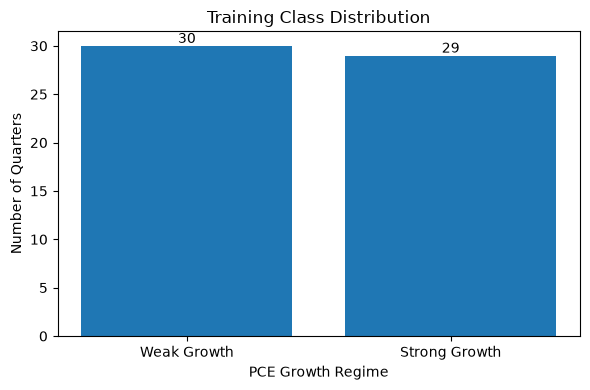

In [10]:
# ============================================================
# CLASS BALANCE VISUALIZATION
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))

train_counts = y_train.value_counts().sort_index()

ax.bar(
    ["Weak Growth", "Strong Growth"],
    train_counts.values
)

ax.set_title("Training Class Distribution")
ax.set_ylabel("Number of Quarters")
ax.set_xlabel("PCE Growth Regime")

for i, value in enumerate(train_counts.values):
    ax.text(
        i,
        value + 0.3,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

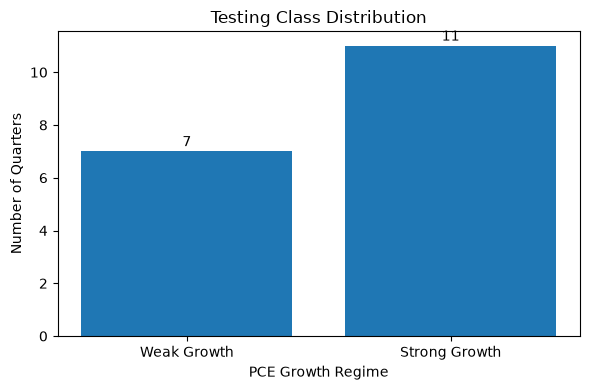

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))

test_counts = y_test.value_counts().sort_index()

ax.bar(
    ["Weak Growth", "Strong Growth"],
    test_counts.values
)

ax.set_title("Testing Class Distribution")
ax.set_ylabel("Number of Quarters")
ax.set_xlabel("PCE Growth Regime")

for i, value in enumerate(test_counts.values):
    ax.text(
        i,
        value + 0.2,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

## 3F — Establish our naive baseline

How well can we perform without learning anything about the 74 economic features?

In [12]:
# ============================================================
# DUMMY CLASSIFIER BASELINE
# ============================================================

from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(
    strategy="most_frequent"
)

# Dummy X values are sufficient here because
# the classifier intentionally ignores predictors.
X_dummy_train = np.zeros((len(y_train), 1))
X_dummy_test  = np.zeros((len(y_test), 1))

dummy.fit(
    X_dummy_train,
    y_train
)

dummy_pred = dummy.predict(
    X_dummy_test
)

print("Dummy prediction:")
print(dummy_pred)

Dummy prediction:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


interpretation : Which class appears most often in training?\
Result: 0 (weak PCE growth)


## 3G — Evaluate the naive model

In [13]:
# ============================================================
# BASELINE EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

dummy_accuracy = accuracy_score(
    y_test,
    dummy_pred
)

dummy_precision = precision_score(
    y_test,
    dummy_pred,
    zero_division=0
)

dummy_recall = recall_score(
    y_test,
    dummy_pred,
    zero_division=0
)

dummy_f1 = f1_score(
    y_test,
    dummy_pred,
    zero_division=0
)

dummy_balanced_accuracy = balanced_accuracy_score(
    y_test,
    dummy_pred
)

print("DUMMY CLASSIFIER BASELINE")
print("=" * 45)

print(f"Accuracy:          {dummy_accuracy:.4f}")
print(f"Precision:         {dummy_precision:.4f}")
print(f"Recall:            {dummy_recall:.4f}")
print(f"F1 Score:          {dummy_f1:.4f}")
print(
    f"Balanced Accuracy: "
    f"{dummy_balanced_accuracy:.4f}"
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dummy_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        dummy_pred,
        target_names=[
            "Weak Growth",
            "Strong Growth"
        ],
        zero_division=0
    )
)

DUMMY CLASSIFIER BASELINE
Accuracy:          0.3889
Precision:         0.0000
Recall:            0.0000
F1 Score:          0.0000
Balanced Accuracy: 0.5000

Confusion Matrix:
[[ 7  0]
 [11  0]]

Classification Report:
               precision    recall  f1-score   support

  Weak Growth       0.39      1.00      0.56         7
Strong Growth       0.00      0.00      0.00        11

     accuracy                           0.39        18
    macro avg       0.19      0.50      0.28        18
 weighted avg       0.15      0.39      0.22        18



#### This becomes our minimum benchmark

## 3H — Add a second baseline

In [14]:
# ============================================================
# STRATIFIED RANDOM BASELINE
# ============================================================

dummy_stratified = DummyClassifier(
    strategy="stratified",
    random_state=42)

dummy_stratified.fit(
    X_dummy_train,
    y_train)
stratified_pred = dummy_stratified.predict(
    X_dummy_test)

print("STRATIFIED DUMMY CLASSIFIER")
print("=" * 45)
print(
    f"Accuracy: "
    f"{accuracy_score(y_test, stratified_pred):.4f}")
print(
    f"F1 Score: "
    f"{f1_score(y_test, stratified_pred, zero_division=0):.4f}")
print(
    f"Balanced Accuracy: "
    f"{balanced_accuracy_score(y_test, stratified_pred):.4f}")
print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        stratified_pred))

STRATIFIED DUMMY CLASSIFIER
Accuracy: 0.4444
F1 Score: 0.5000
Balanced Accuracy: 0.4416

Confusion Matrix:
[[3 4]
 [6 5]]


#### Interpretation: 
`stratified` randomly predicts classes according to the **training class distribution**.

## 3I — Decide whether resampling is currently necessary

Do we need to apply SMOTE? 

No.\
The median-based target definition **naturally produced balanced training classes**, so resampling is not required for the primary classification experiment.

However, we will retain the resampling experiment later, once we changed our **target threshold** to: 

PCE≤0 vs PCE>0

it may shows **10:67** ---> a good case for resampling experiment  

## Conclusion: 

1. We confirm that our **training-median threshold of 0.5576%** worked as intended based on the **IR = 30/29= 1.034** whcih is essentially perfect balance. As a result, we decided not to use SMOTE, oversampling, undersampling, or class weighting on the primary dataset.
2. Test data: naturally different, but acceptable. IR= 11/7= 1.571 is a indicator of moderate natural imbalance. 
3. Class 0 (weak PCE growth) is technically the most frequent class—even though only by one observation through the dummyclassifier validation
4. Understanding the confusion matrix:\
   Obtained: 
   $$
\begin{bmatrix}
7 & 0 \\
11 & 0
\end{bmatrix}
$$
The standard binary confusion matrix: 
$$
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$
our result corresponds to:
$$
\begin{bmatrix}
TN=7 & FP=0 \\
FN=11 & TP=0
\end{bmatrix}
$$



|                   | Predicted Weak | Predicted Strong |
| ----------------- | -------------: | ---------------: |
| **Actual Weak**   |          **7** |                0 |
| **Actual Strong** |         **11** |            **0** |


5. Our Balanced Accuracy =0.50 gives us an useful benchmark.

6. The stratified baseline provide us anther reference

| Model               | Accuracy | Balanced Accuracy |    F1 |
| ------------------- | -------: | ----------------: | ----: |
| Most-frequent Dummy |    0.389 |         **0.500** | 0.000 |
| Stratified Dummy    |    0.444 |             0.442 | 0.500 |
| Logistic Regression |        ? |                 ? |     ? |
| KNN                 |        ? |                 ? |     ? |
| SVM                 |        ? |                 ? |     ? |
| Decision Tree       |        ? |                 ? |     ? |
| Random Forest       |        ? |                 ? |     ? |
| XGBoost             |        ? |                 ? |     ? |


7. We defined our primary evaluation metrics:
    - **Balanced Accuracy**
    - Ordinary Accuracy
    - **F1**
    - Precision
    - Recall
    - Confusion Matrix
    - ROC-AUC 


The training dataset contains **30 weak-growth** and **29 strong-growth** observations, producing an **imbalance ratio of 1.034**.

Therefore, the primary classification problem is effectively balanced and **does not require resampling**. The chronological test set contains 7 weak-growth and 11 strong-growth observations (IR = 1.571), representing a moderate but naturally occurring future class imbalance. 

The most-frequent and stratified DummyClassifier models establish baseline performance of 38.9% and 44.4% accuracy, respectively. These results provide minimum benchmarks against which subsequent supervised classification models will be evaluated.